# スコアへの到達の仕方別の次の得点までの待ち時間

同じスコアでも、自分の得点でそのスコアになったのか、相手の得点でなったのかで、その後の点の取りやすさが変わるかを調べる。

### 調べるパターン
スコアは「自分の得点-相手の得点」で表す。

| # | 起点のスコア | 直近得点 | 直近失点 |
|---|---|---|---|
| 1 | 1-1 | 0-1から追いついた | 1-0から追いつかれた |
| 2 | 2-1 | 1-1から勝ち越した | 2-0から1点返された |
| 3 | 1-2 | 0-2から1点返した | 1-1から勝ち越された |
| 4 | 2-2 | 1-2から追いついた | 2-1から追いつかれた |

## 分析の考え方

各チームから見たスコア（自分の得点 own、相手の得点 opp）を追いかけて、起点のスコアになった瞬間から、自分の次の得点までの時間を測る。

- **直近得点**：自分の得点で起点のスコアになった
- **直近失点**：相手の得点で起点のスコアになった

起点のスコアを通らなかった試合は使わない。

### 観測の終わり方
| 終わり方 | 内容 |
|---|---|
| イベント | 自チームが得点した |
| 打ち切り（相手の得点） | 先に相手が得点した（図では赤） |
| 打ち切り（試合終了） | 得点がないまま試合が終わった（図では青） |

In [176]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# グラフの日本語が文字化けしないようにする
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

# 図で使う色
CENSOR_OPPONENT_COLOR = "red"   # 相手の得点による打ち切り
CENSOR_MATCHEND_COLOR = "blue"  # 試合終了による打ち切り
MEDIAN_COLOR = "#009E73"        # 生存時間中央値の線

# 直近得点・直近失点の色
OWN_GOAL_COLOR = "#E69F00"   # 直近得点
OPP_GOAL_COLOR = "#56B4E9"   # 直近失点


## 得点遷移グラフ

横軸を自分の得点、縦軸を相手の得点にしたマス目で、スコアの動きを表す。自分が得点すると右へ、相手が得点すると上へ1マス進む。

起点のスコアへの入り方（赤：自分の得点、青：相手の得点）と、そこから測る得点（点線）を描く関数を作る。

In [177]:
# 遷移グラフの大きさと、軸の範囲（0〜4）
TRANSITION_DIAGRAM_FIGSIZE = (7.5, 6.5)
TRANSITION_DIAGRAM_MAX = 4

def plot_transition_diagram(target_own, target_opp, title=None, ax=None):
    """起点のスコア (target_own, target_opp) への入り方と、そこから測る得点を
    マス目の上に描く
    """
    max_own = TRANSITION_DIAGRAM_MAX
    max_opp = TRANSITION_DIAGRAM_MAX
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=TRANSITION_DIAGRAM_FIGSIZE)
        created_fig = True
    else:
        fig = ax.figure

    # 起点への矢印の色（自分の得点＝赤、相手の得点＝青）
    TRANSITION_OWN_COLOR = "red"
    TRANSITION_OPP_COLOR = "blue"

    # スコアの点
    for o in range(max_own + 1):
        for p in range(max_opp + 1):
            ax.scatter(o, p, s=180, color="black", zorder=3)

    # 起こりうる動き（薄い矢印）
    for o in range(max_own):
        for p in range(max_opp + 1):
            ax.annotate("", xy=(o + 1, p), xytext=(o, p),
                        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2, alpha=0.35), zorder=1)
    for o in range(max_own + 1):
        for p in range(max_opp):
            ax.annotate("", xy=(o, p + 1), xytext=(o, p),
                        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2, alpha=0.35), zorder=1)

    # 起点のスコアへの入り方（太い矢印）
    if target_own - 1 >= 0:
        ax.annotate("", xy=(target_own, target_opp), xytext=(target_own - 1, target_opp),
                    arrowprops=dict(arrowstyle="-|>", color=TRANSITION_OWN_COLOR, lw=3.5), zorder=2)
    if target_opp - 1 >= 0:
        ax.annotate("", xy=(target_own, target_opp), xytext=(target_own, target_opp - 1),
                    arrowprops=dict(arrowstyle="-|>", color=TRANSITION_OPP_COLOR, lw=3.5), zorder=2)

    # 起点から測る得点（点線の矢印）
    if target_own + 1 <= max_own:
        ax.annotate("", xy=(target_own + 1, target_opp), xytext=(target_own, target_opp),
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=2.5, linestyle="--"), zorder=2)

    ax.set_xlim(-0.5, max_own + 0.5)
    ax.set_ylim(-0.5, max_opp + 0.5)
    ax.set_xlabel("自分の得点数 own → 横軸＝最後の得点の「主人公」が自分かどうかを表す", fontsize=10.5)
    ax.set_ylabel("相手の得点数 opp", fontsize=10.5)
    if title is not None:
        ax.set_title(title, fontsize=11)
    ax.set_xticks(range(max_own + 1))
    ax.set_yticks(range(max_opp + 1))
    ax.set_aspect("equal")
    ax.grid(alpha=0.15)

    if created_fig:
        fig.tight_layout()
    return fig, ax

## 1. データの読み込み

`statsbomb_data` にある全リーグ・全シーズンの `*_goals_and_red_cards.csv` を読み込んで、1つの表にまとめる。

In [178]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461


## 2. 共通で使う関数

4つのパターンで同じことをするので、関数にまとめておく。

- `build_arrival_split_events`：起点のスコアに着いた場面を集め、直近得点・直近失点に分けて待ち時間を作る
- `fit_km_by_category`：区分ごとにKaplan-Meier曲線を当てはめる
- `plot_hist_with_km_median`：ヒストグラムを描く
- `plot_km_with_censor_marks`：Kaplan-Meier曲線を描く
- `run_logrank_tests`：ログランク検定をする

In [179]:
def build_arrival_split_events(df, target_own, target_opp):
    """起点のスコアになった場面を集め、直近得点・直近失点に分けて、
    そこから自分の次の得点までの待ち時間を作る
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)
    group_cols = ["league_code", "season_name", "match_id"]
    goal_groups = {key: g.sort_values("time_min") for key, g in goal_rows.groupby(group_cols)}

    end_rows = df[df["red_card"].isna() & df["home_away"].isna() & df["end_time_minutes"].notna()].copy()
    end_rows["full_time_min"] = end_rows["end_time_minutes"].astype(float) + end_rows["end_time_second"].astype(float) / 60.0

    records = []
    for row in end_rows.itertuples(index=False):
        key = (row.league_code, row.season_name, row.match_id)
        full_time = row.full_time_min
        meta = dict(league_code=row.league_code, season_name=row.season_name, match_id=row.match_id)

        g = goal_groups.get(key)
        if g is None:
            times = np.array([])
            sides = np.array([], dtype=int)
        else:
            times = g["time_min"].to_numpy()
            sides = g["home_away"].to_numpy()  # 0=home, 1=away
        k = len(times)

        for side in (0, 1):  # 0=home視点, 1=away視点
            own_score = opp_score = 0
            arrived = False
            arrival_time = None
            arrival_index = None
            direction = None
            for i in range(k):
                t_i = float(times[i])
                s_i = int(sides[i])
                if s_i == side:
                    own_score += 1
                else:
                    opp_score += 1
                if not arrived and own_score == target_own and opp_score == target_opp:
                    arrived = True
                    arrival_time = t_i
                    arrival_index = i
                    direction = "直近得点" if s_i == side else "直近失点"
                    break  # 起点のスコアになるのは1試合に1回だけ

            if not arrived:
                continue

            if arrival_index + 1 < k:
                t_next = float(times[arrival_index + 1])
                s_next = int(sides[arrival_index + 1])
                if s_next == side:
                    event, censor_type = 1, None
                else:
                    event, censor_type = 0, "opponent"
                waiting_time = t_next - arrival_time
            else:
                event, censor_type = 0, "match_end"
                waiting_time = full_time - arrival_time

            records.append({
                **meta, "team": "home" if side == 0 else "away",
                "category": direction, "waiting_time": waiting_time,
                "event": event, "censor_type": censor_type,
            })

    return pd.DataFrame(records)


try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test
except ModuleNotFoundError:
    # lifelines がなければインストールする
    # インストールしたら、カーネルを再起動してから実行し直す
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "lifelines"])
    raise RuntimeError(
        "lifelines をインストールしました。numpy/matplotlib との整合性のため、"
        "カーネルを再起動してから、このセルより上から再実行してください。"
    )


def fit_km_by_category(survival_df, category_order):
    """区分ごとに Kaplan-Meier 曲線を当てはめ、{区分: 結果} の辞書と集計表を返す"""
    km_fits = {}
    summary_rows = []
    for cat in category_order:
        sub = survival_df[survival_df["category"] == cat]
        n = len(sub)
        if n == 0:
            km_fits[cat] = None
            summary_rows.append({"区分": cat, "n": 0, "イベント数": 0,
                                  "相手の得点による打ち切り": 0, "試合終了による打ち切り": 0,
                                  "生存時間中央値me(分)": np.nan})
            continue
        n_event = int((sub["event"] == 1).sum())
        n_cens_opp = int((sub["censor_type"] == "opponent").sum())
        n_cens_end = int((sub["censor_type"] == "match_end").sum())
        kmf = KaplanMeierFitter()
        kmf.fit(durations=sub["waiting_time"], event_observed=sub["event"], label=f"{cat} (n={n})")
        km_fits[cat] = kmf
        summary_rows.append({"区分": cat, "n": n, "イベント数": n_event,
                              "相手の得点による打ち切り": n_cens_opp, "試合終了による打ち切り": n_cens_end,
                              "生存時間中央値me(分)": kmf.median_survival_time_})
    summary = pd.DataFrame(summary_rows).set_index("区分").reindex(category_order)
    return km_fits, summary


BAR_COLOR = "#6699CC"


def plot_hist_with_km_median(ax, sub_df, kmf, title, bin_edges):
    vals = sub_df["waiting_time"].values
    n = len(vals)
    n_event = int((sub_df["event"] == 1).sum())
    n_cens = n - n_event

    counts, _ = np.histogram(vals, bins=bin_edges)
    ax.bar(bin_edges[:-1], counts, width=bin_edges[1] - bin_edges[0], align="edge",
           color=BAR_COLOR, edgecolor="white", linewidth=0.5)

    if kmf is not None:
        me = kmf.median_survival_time_
        if np.isfinite(me):
            ax.axvline(me, color=MEDIAN_COLOR, linestyle=":", linewidth=1.8,
                        label=f"生存時間中央値 me={me:.1f}分")
            ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

    ax.set_title(f"{title} (n={n}, イベント={n_event}, 打ち切り={n_cens})", fontsize=10)
    ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
    ax.set_ylabel("度数")
    ax.grid(axis="y", alpha=0.3)


def plot_km_with_censor_marks(ax, sub_df, kmf, title, tick_height=0.025):
    n = len(sub_df)
    n_event = int((sub_df["event"] == 1).sum())

    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False, legend=False,
                                color="black", linewidth=1.5)

    for censor_type, color in [("opponent", CENSOR_OPPONENT_COLOR), ("match_end", CENSOR_MATCHEND_COLOR)]:
        t_cens = sub_df.loc[sub_df["censor_type"] == censor_type, "waiting_time"].values
        if len(t_cens) == 0:
            continue
        s_vals = kmf.survival_function_at_times(t_cens).values
        ax.vlines(t_cens, s_vals - tick_height, s_vals + tick_height,
                   color=color, linewidth=0.8, alpha=0.5)

    # S(t)=0.5 の水平線
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)

    # 生存時間中央値の縦線と数字
    me = kmf.median_survival_time_
    if np.isfinite(me):
        ax.axvline(me, color=MEDIAN_COLOR, linestyle=":", linewidth=1.5)
        ax.annotate(f"me={me:.1f}分", xy=(me, 0.5), xytext=(6, 6),
                    textcoords="offset points", fontsize=8, color=MEDIAN_COLOR,
                    fontweight="bold")

    ax.set_title(f"{title} (n={n}, イベント={n_event})", fontsize=10)
    ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
    ax.set_ylabel("生存確率")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)


def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""


def run_logrank_tests(survival_df, category_order):
    """まとめて比べる検定と、2区分ずつ比べる検定（Bonferroni補正つき）をする"""
    overall_result = multivariate_logrank_test(
        event_durations=survival_df["waiting_time"],
        groups=survival_df["category"],
        event_observed=survival_df["event"],
    )
    print(f"=== {len(category_order)}区分一括のログランク検定（打ち切りを考慮） ===")
    overall_result.print_summary()

    pairwise_result = pairwise_logrank_test(
        event_durations=survival_df["waiting_time"],
        groups=survival_df["category"],
        event_observed=survival_df["event"],
    )
    pairwise_summary = pairwise_result.summary.copy()
    n_comparisons = len(pairwise_summary)
    pairwise_summary["p_bonferroni"] = (pairwise_summary["p"] * n_comparisons).clip(upper=1.0)
    pairwise_summary = pairwise_summary.sort_values("p")
    pairwise_summary["p"] = pairwise_summary["p"].apply(lambda v: f"{v:.6e}{stars(v)}")
    pairwise_summary["p_bonferroni"] = pairwise_summary["p_bonferroni"].apply(lambda v: f"{v:.6e}{stars(v)}")

    print(f"\n=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数={n_comparisons}） ===")
    print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")
    return pairwise_summary


## パターン1：1-1

- 直近得点：0-1から追いついて1-1
- 直近失点：1-0から追いつかれて1-1

保存しました: ./figures/survival_score_progression_1_1_to_2_1_transition_diagram.png


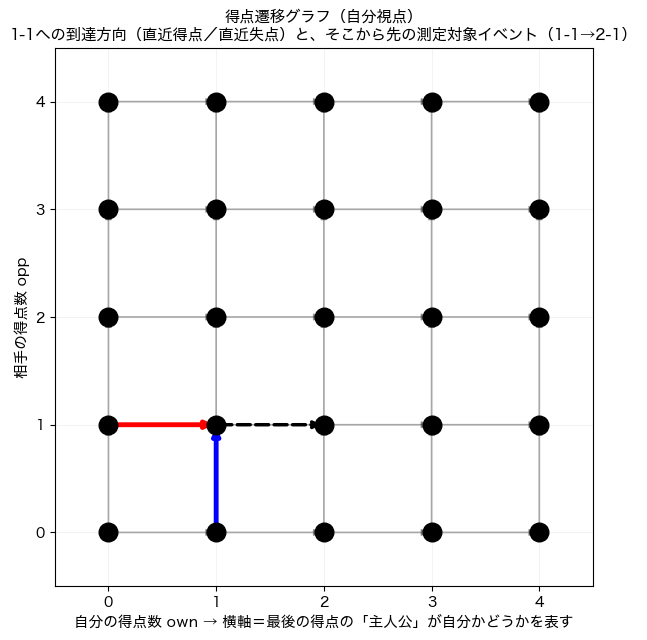

In [180]:
fig, ax = plot_transition_diagram(
    target_own=1, target_opp=1,
    title="得点遷移グラフ（自分視点）\n1-1への到達方向（直近得点／直近失点）と、そこから先の測定対象イベント（1-1→2-1）",
)

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_1_1_to_2_1_transition_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()

In [181]:
CATEGORY_ORDER_1 = ["直近得点", "直近失点"]

survival_df_1 = build_arrival_split_events(df_all, target_own=1, target_opp=1)
n_event = int((survival_df_1["event"] == 1).sum())
n_cens_opp = int((survival_df_1["censor_type"] == "opponent").sum())
n_cens_end = int((survival_df_1["censor_type"] == "match_end").sum())
print(f"観測数: {len(survival_df_1)}（イベント: {n_event}, 相手の得点による打ち切り: {n_cens_opp}, "
      f"試合終了による打ち切り: {n_cens_end}）")

survival_df_1.groupby(["category", "event"]).size().unstack(fill_value=0).reindex(CATEGORY_ORDER_1)


観測数: 1640（イベント: 538, 相手の得点による打ち切り: 538, 試合終了による打ち切り: 564）


event,0,1
category,,
直近得点,547,273
直近失点,555,265


In [182]:
BIN_WIDTH = 5  # 分
max_wait_1 = survival_df_1["waiting_time"].max()
BIN_EDGES_1 = np.arange(0, np.ceil(max_wait_1 / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait_1:.2f}分 -> ビン境界: 0〜{BIN_EDGES_1[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES_1)-1}ビン）")

km_fits_1, km_summary_1 = fit_km_by_category(survival_df_1, CATEGORY_ORDER_1)
km_summary_1


最大待ち時間: 90.17分 -> ビン境界: 0〜95分（5分刻み、19ビン）


,n,イベント数,相手の得点による打ち切り,試合終了による打ち切り,生存時間中央値me(分)
区分,,,,,
直近得点,820,273,265,282,48.000000
直近失点,820,265,273,282,47.083333


保存しました: ./figures/survival_score_progression_1_1_to_2_1_histograms.png


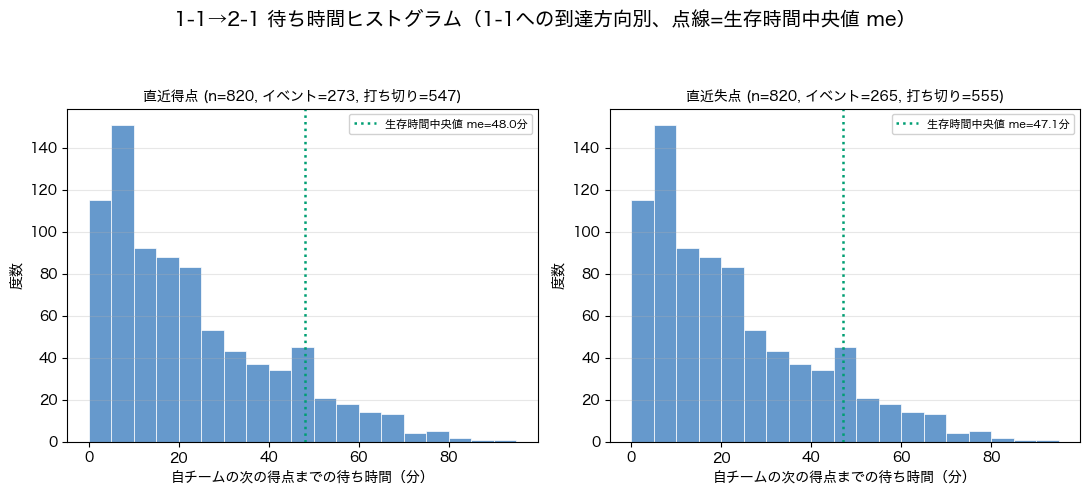

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, cat in zip(axes, CATEGORY_ORDER_1):
    sub = survival_df_1[survival_df_1["category"] == cat]
    plot_hist_with_km_median(ax, sub, km_fits_1[cat], cat, BIN_EDGES_1)

fig.suptitle("1-1→2-1 待ち時間ヒストグラム（1-1への到達方向別、点線=生存時間中央値 me）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_1_1_to_2_1_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


保存しました: ./figures/survival_score_progression_1_1_to_2_1_km_curves_grid.png


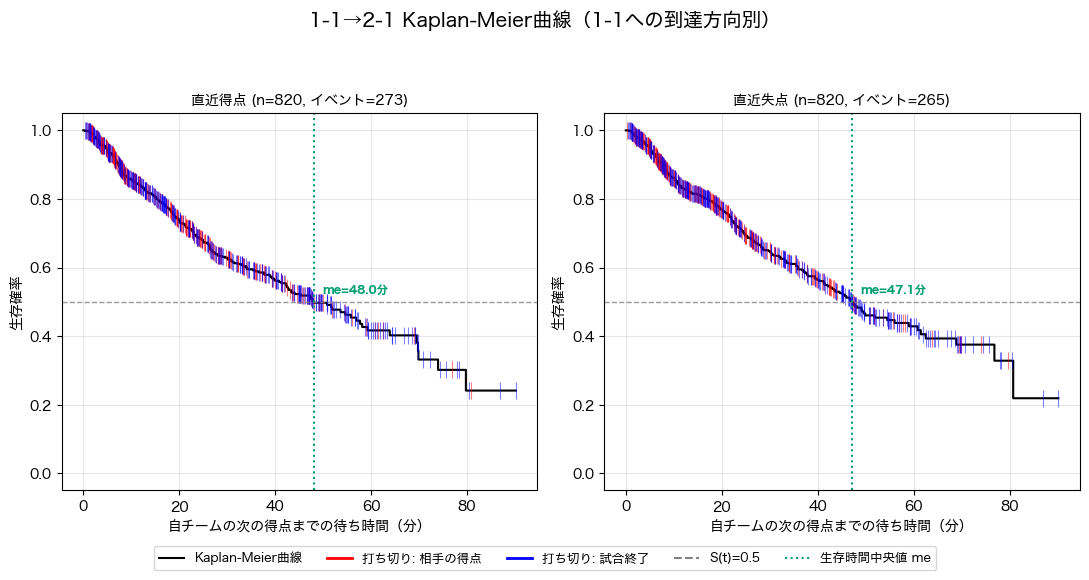

In [184]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

for ax, cat in zip(axes, CATEGORY_ORDER_1):
    kmf = km_fits_1[cat]
    sub = survival_df_1[survival_df_1["category"] == cat]
    if kmf is None:
        ax.axis("off")
        continue
    plot_km_with_censor_marks(ax, sub, kmf, cat)

legend_handles = [
    Line2D([], [], color="black", linewidth=1.5, label="Kaplan-Meier曲線"),
    Line2D([], [], color=CENSOR_OPPONENT_COLOR, linewidth=2, label="打ち切り: 相手の得点"),
    Line2D([], [], color=CENSOR_MATCHEND_COLOR, linewidth=2, label="打ち切り: 試合終了"),
    Line2D([], [], color="gray", linewidth=1.5, linestyle="--", label="S(t)=0.5"),
    Line2D([], [], color=MEDIAN_COLOR, linewidth=1.5, linestyle=":", label="生存時間中央値 me"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.05))

fig.suptitle("1-1→2-1 Kaplan-Meier曲線（1-1への到達方向別）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_1_1_to_2_1_km_curves_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"保存しました: {out_path}")
plt.show()


保存しました: ./figures/survival_score_progression_1_1_to_2_1_km_curves_overlay.png


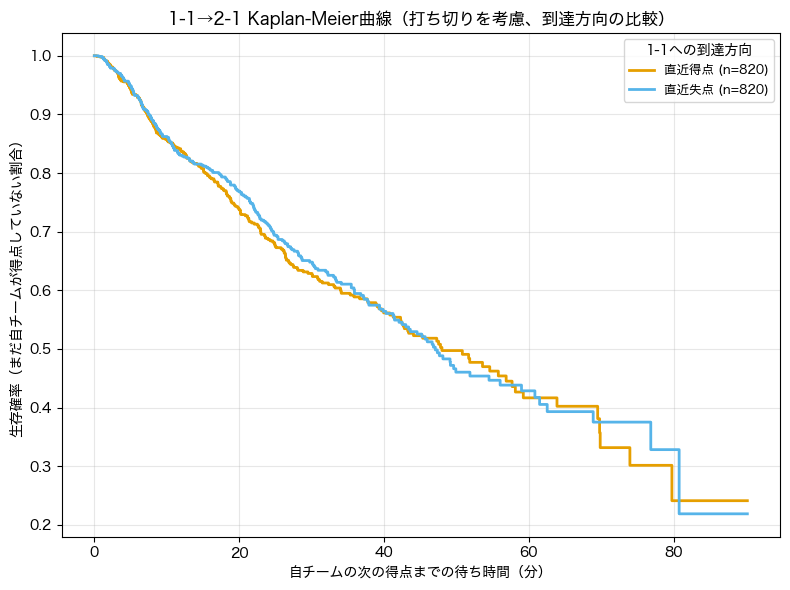

In [185]:
CATEGORY_COLORS_1 = {"直近得点": OWN_GOAL_COLOR, "直近失点": OPP_GOAL_COLOR}

fig, ax = plt.subplots(figsize=(8, 6))

for cat in CATEGORY_ORDER_1:
    kmf = km_fits_1[cat]
    if kmf is None:
        continue
    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                color=CATEGORY_COLORS_1[cat], linewidth=2)

ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ自チームが得点していない割合）")
ax.set_title("1-1→2-1 Kaplan-Meier曲線（打ち切りを考慮、到達方向の比較）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right", title="1-1への到達方向")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_1_1_to_2_1_km_curves_overlay.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [186]:
pairwise_summary_1 = run_logrank_tests(survival_df_1, CATEGORY_ORDER_1)
pairwise_summary_1


=== 2区分一括のログランク検定（打ち切りを考慮） ===



=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数=1） ===
有意水準: * p<0.10, ** p<0.05, *** p<0.01


,,test_statistic,p,-log2(p),p_bonferroni
直近失点,直近得点,0.118971,7.301535e-01,0.453728,7.301535e-01


## パターン2：2-1

- 直近得点：1-1から勝ち越して2-1
- 直近失点：2-0から1点返されて2-1

保存しました: ./figures/survival_score_progression_2_1_to_3_1_transition_diagram.png


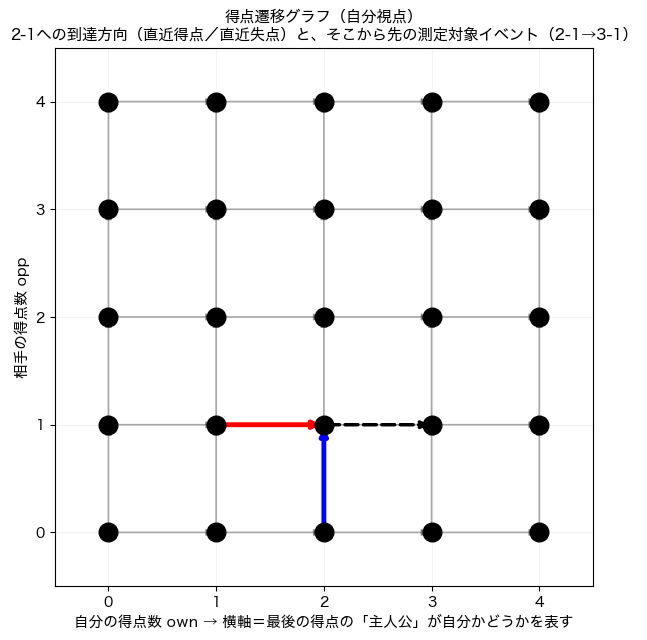

In [187]:
fig, ax = plot_transition_diagram(
    target_own=2, target_opp=1,
    title="得点遷移グラフ（自分視点）\n2-1への到達方向（直近得点／直近失点）と、そこから先の測定対象イベント（2-1→3-1）",
)

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_1_to_3_1_transition_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [188]:
CATEGORY_ORDER_2 = ["直近得点", "直近失点"]

survival_df_2 = build_arrival_split_events(df_all, target_own=2, target_opp=1)
n_event = int((survival_df_2["event"] == 1).sum())
n_cens_opp = int((survival_df_2["censor_type"] == "opponent").sum())
n_cens_end = int((survival_df_2["censor_type"] == "match_end").sum())
print(f"観測数: {len(survival_df_2)}（イベント: {n_event}, 相手の得点による打ち切り: {n_cens_opp}, "
      f"試合終了による打ち切り: {n_cens_end}）")

survival_df_2.groupby(["category", "event"]).size().unstack(fill_value=0).reindex(CATEGORY_ORDER_2)


観測数: 823（イベント: 261, 相手の得点による打ち切り: 210, 試合終了による打ち切り: 352）


event,0,1
category,,
直近得点,361,177
直近失点,201,84


In [189]:
max_wait_2 = survival_df_2["waiting_time"].max()
BIN_EDGES_2 = np.arange(0, np.ceil(max_wait_2 / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait_2:.2f}分 -> ビン境界: 0〜{BIN_EDGES_2[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES_2)-1}ビン）")

km_fits_2, km_summary_2 = fit_km_by_category(survival_df_2, CATEGORY_ORDER_2)
km_summary_2


最大待ち時間: 75.08分 -> ビン境界: 0〜80分（5分刻み、16ビン）


,n,イベント数,相手の得点による打ち切り,試合終了による打ち切り,生存時間中央値me(分)
区分,,,,,
直近得点,538,177,133,228,36.833333
直近失点,285,84,77,124,42.150000


保存しました: ./figures/survival_score_progression_2_1_to_3_1_histograms.png


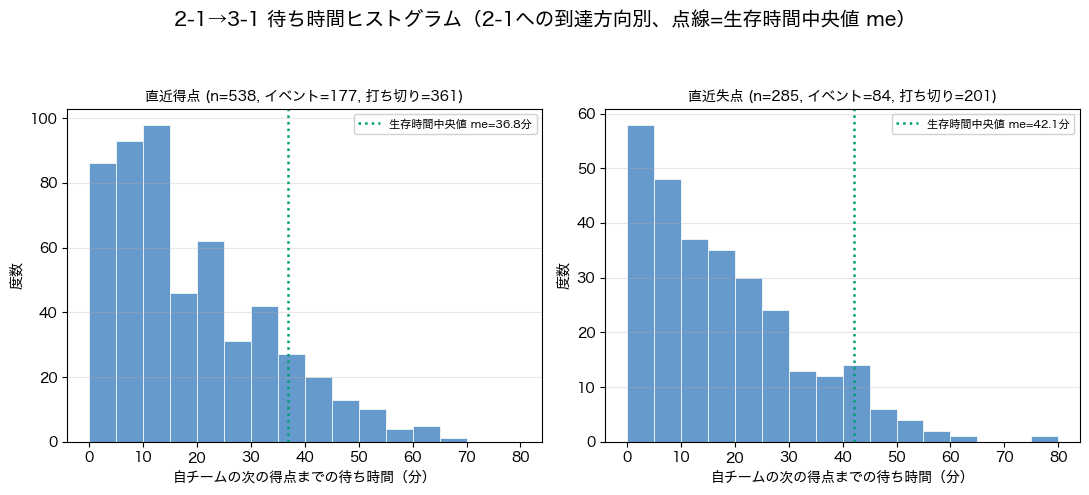

In [190]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, cat in zip(axes, CATEGORY_ORDER_2):
    sub = survival_df_2[survival_df_2["category"] == cat]
    plot_hist_with_km_median(ax, sub, km_fits_2[cat], cat, BIN_EDGES_2)

fig.suptitle("2-1→3-1 待ち時間ヒストグラム（2-1への到達方向別、点線=生存時間中央値 me）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_1_to_3_1_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


保存しました: ./figures/survival_score_progression_2_1_to_3_1_km_curves_grid.png


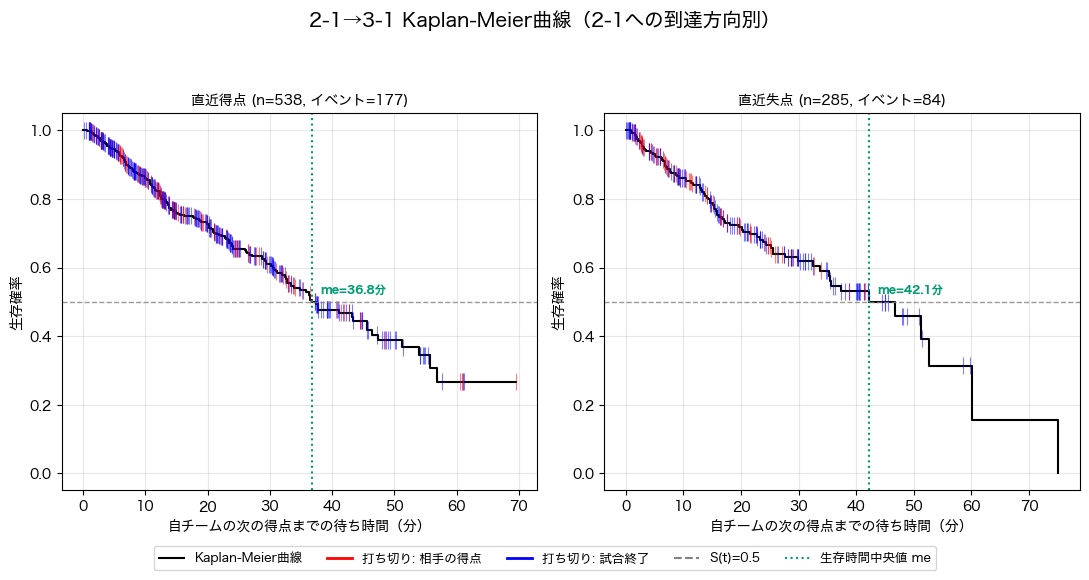

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

for ax, cat in zip(axes, CATEGORY_ORDER_2):
    kmf = km_fits_2[cat]
    sub = survival_df_2[survival_df_2["category"] == cat]
    if kmf is None:
        ax.axis("off")
        continue
    plot_km_with_censor_marks(ax, sub, kmf, cat)

legend_handles = [
    Line2D([], [], color="black", linewidth=1.5, label="Kaplan-Meier曲線"),
    Line2D([], [], color=CENSOR_OPPONENT_COLOR, linewidth=2, label="打ち切り: 相手の得点"),
    Line2D([], [], color=CENSOR_MATCHEND_COLOR, linewidth=2, label="打ち切り: 試合終了"),
    Line2D([], [], color="gray", linewidth=1.5, linestyle="--", label="S(t)=0.5"),
    Line2D([], [], color=MEDIAN_COLOR, linewidth=1.5, linestyle=":", label="生存時間中央値 me"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.05))

fig.suptitle("2-1→3-1 Kaplan-Meier曲線（2-1への到達方向別）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_1_to_3_1_km_curves_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"保存しました: {out_path}")
plt.show()


保存しました: ./figures/survival_score_progression_2_1_to_3_1_km_curves_overlay.png


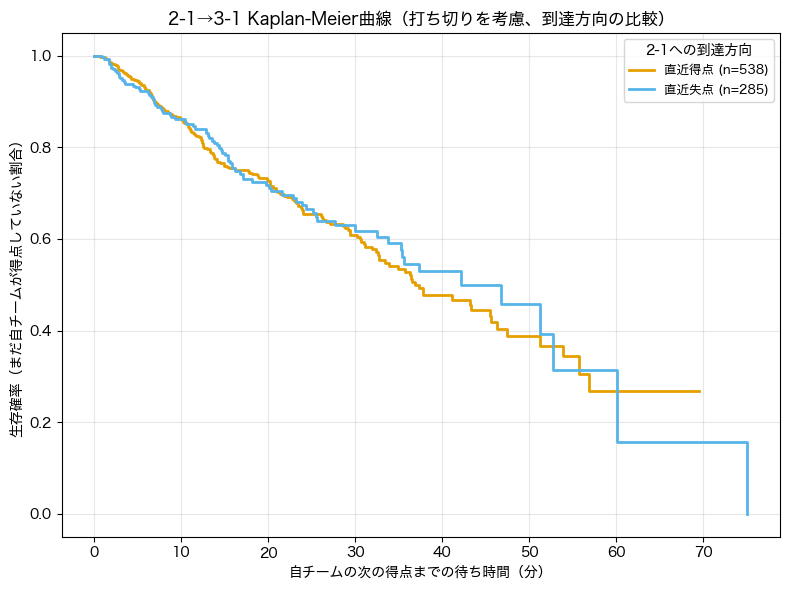

In [192]:
CATEGORY_COLORS_2 = {"直近得点": OWN_GOAL_COLOR, "直近失点": OPP_GOAL_COLOR}

fig, ax = plt.subplots(figsize=(8, 6))

for cat in CATEGORY_ORDER_2:
    kmf = km_fits_2[cat]
    if kmf is None:
        continue
    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                color=CATEGORY_COLORS_2[cat], linewidth=2)

ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ自チームが得点していない割合）")
ax.set_title("2-1→3-1 Kaplan-Meier曲線（打ち切りを考慮、到達方向の比較）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right", title="2-1への到達方向")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_1_to_3_1_km_curves_overlay.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [193]:
pairwise_summary_2 = run_logrank_tests(survival_df_2, CATEGORY_ORDER_2)
pairwise_summary_2


=== 2区分一括のログランク検定（打ち切りを考慮） ===



=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数=1） ===
有意水準: * p<0.10, ** p<0.05, *** p<0.01


,,test_statistic,p,-log2(p),p_bonferroni
直近失点,直近得点,0.156932,6.919972e-01,0.531162,6.919972e-01


## パターン3：1-2

負けている側から見たスコア。ここから自分が点を取ると2-2になる。

- 直近得点：0-2から1点返して1-2
- 直近失点：1-1から勝ち越されて1-2

保存しました: ./figures/survival_score_progression_2_1_to_2_2_transition_diagram.png


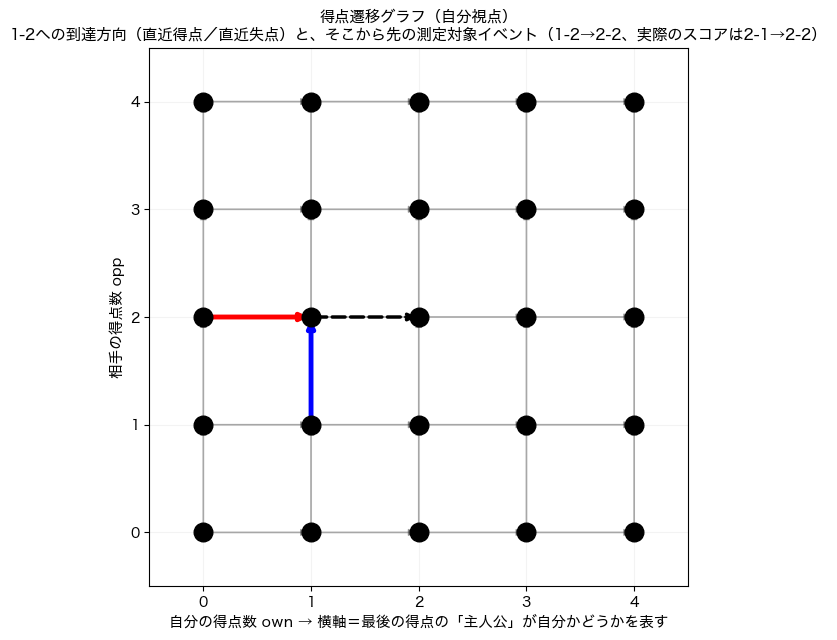

In [194]:
fig, ax = plot_transition_diagram(
    target_own=1, target_opp=2,
    title="得点遷移グラフ（自分視点）\n1-2への到達方向（直近得点／直近失点）と、そこから先の測定対象イベント（1-2→2-2、実際のスコアは2-1→2-2）",
)

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_1_to_2_2_transition_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [195]:
CATEGORY_ORDER_3 = ["直近得点", "直近失点"]

survival_df_3 = build_arrival_split_events(df_all, target_own=1, target_opp=2)
n_event = int((survival_df_3["event"] == 1).sum())
n_cens_opp = int((survival_df_3["censor_type"] == "opponent").sum())
n_cens_end = int((survival_df_3["censor_type"] == "match_end").sum())
print(f"観測数: {len(survival_df_3)}（イベント: {n_event}, 相手の得点による打ち切り: {n_cens_opp}, "
      f"試合終了による打ち切り: {n_cens_end}）")

survival_df_3.groupby(["category", "event"]).size().unstack(fill_value=0).reindex(CATEGORY_ORDER_3)


観測数: 823（イベント: 210, 相手の得点による打ち切り: 261, 試合終了による打ち切り: 352）


event,0,1
category,,
直近得点,208,77
直近失点,405,133


In [196]:
max_wait_3 = survival_df_3["waiting_time"].max()
BIN_EDGES_3 = np.arange(0, np.ceil(max_wait_3 / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait_3:.2f}分 -> ビン境界: 0〜{BIN_EDGES_3[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES_3)-1}ビン）")

km_fits_3, km_summary_3 = fit_km_by_category(survival_df_3, CATEGORY_ORDER_3)
km_summary_3


最大待ち時間: 75.08分 -> ビン境界: 0〜80分（5分刻み、16ビン）


,n,イベント数,相手の得点による打ち切り,試合終了による打ち切り,生存時間中央値me(分)
区分,,,,,
直近得点,285,77,84,124,inf
直近失点,538,133,177,228,48.45


保存しました: ./figures/survival_score_progression_2_1_to_2_2_histograms.png


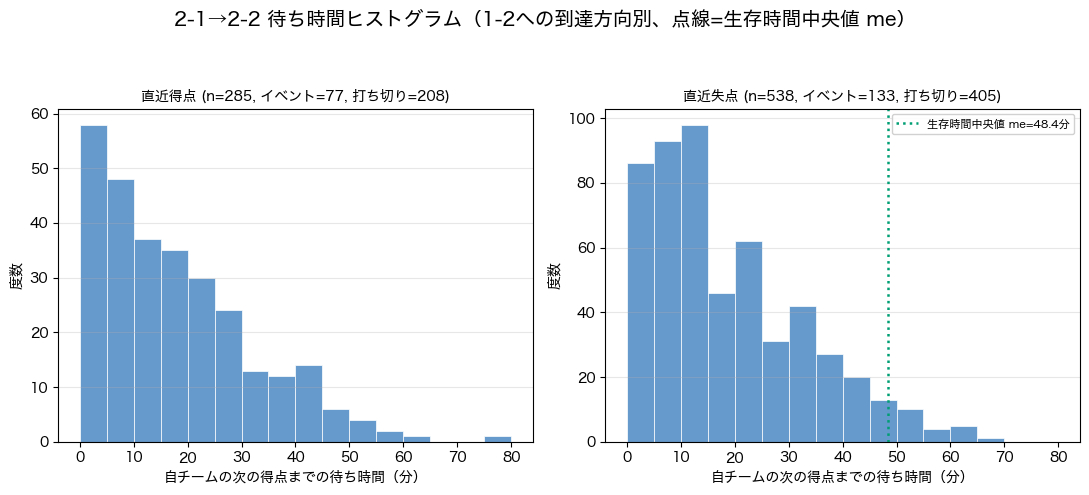

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, cat in zip(axes, CATEGORY_ORDER_3):
    sub = survival_df_3[survival_df_3["category"] == cat]
    plot_hist_with_km_median(ax, sub, km_fits_3[cat], cat, BIN_EDGES_3)

fig.suptitle("2-1→2-2 待ち時間ヒストグラム（1-2への到達方向別、点線=生存時間中央値 me）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_1_to_2_2_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


保存しました: ./figures/survival_score_progression_2_1_to_2_2_km_curves_grid.png


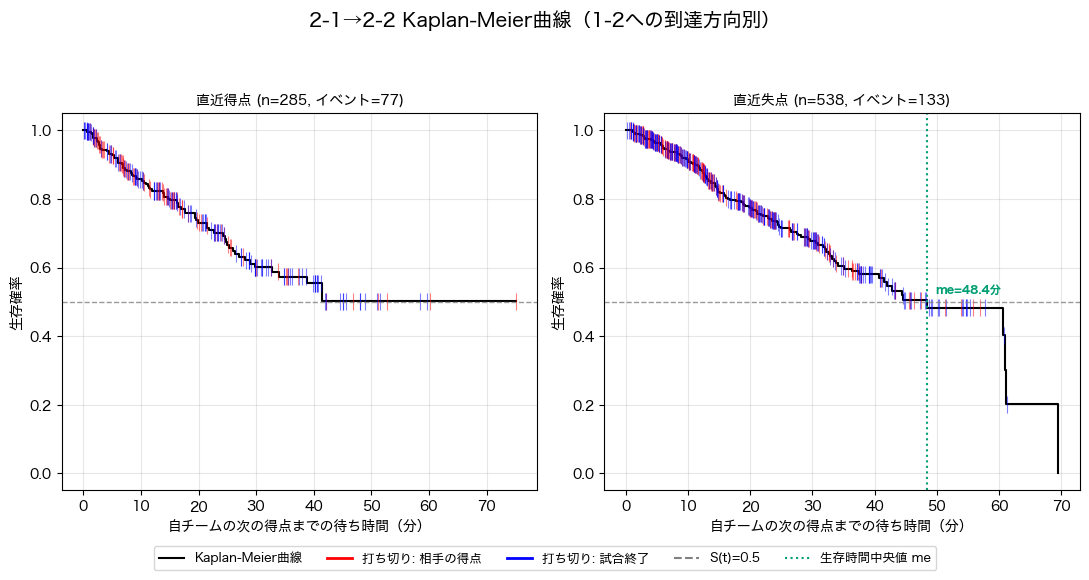

In [198]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

for ax, cat in zip(axes, CATEGORY_ORDER_3):
    kmf = km_fits_3[cat]
    sub = survival_df_3[survival_df_3["category"] == cat]
    if kmf is None:
        ax.axis("off")
        continue
    plot_km_with_censor_marks(ax, sub, kmf, cat)

legend_handles = [
    Line2D([], [], color="black", linewidth=1.5, label="Kaplan-Meier曲線"),
    Line2D([], [], color=CENSOR_OPPONENT_COLOR, linewidth=2, label="打ち切り: 相手の得点"),
    Line2D([], [], color=CENSOR_MATCHEND_COLOR, linewidth=2, label="打ち切り: 試合終了"),
    Line2D([], [], color="gray", linewidth=1.5, linestyle="--", label="S(t)=0.5"),
    Line2D([], [], color=MEDIAN_COLOR, linewidth=1.5, linestyle=":", label="生存時間中央値 me"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.05))

fig.suptitle("2-1→2-2 Kaplan-Meier曲線（1-2への到達方向別）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_1_to_2_2_km_curves_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"保存しました: {out_path}")
plt.show()


保存しました: ./figures/survival_score_progression_2_1_to_2_2_km_curves_overlay.png


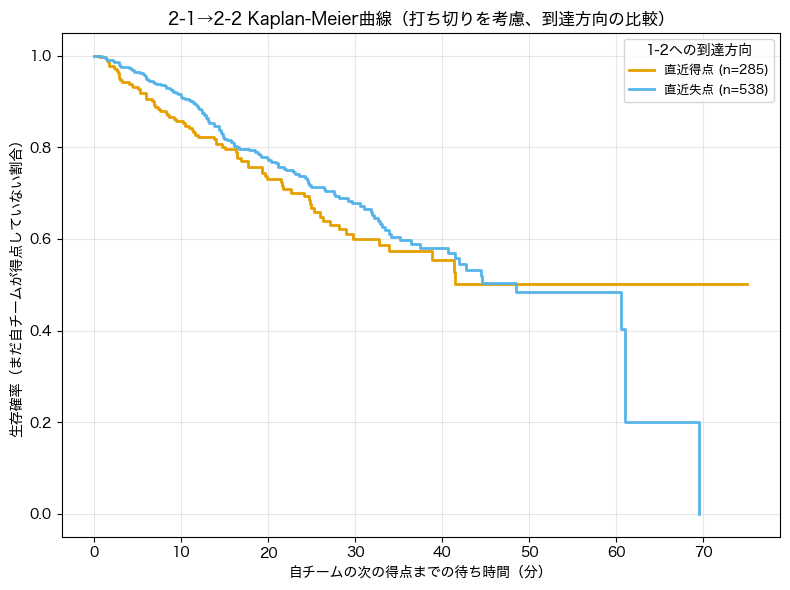

In [199]:
CATEGORY_COLORS_3 = {"直近得点": OWN_GOAL_COLOR, "直近失点": OPP_GOAL_COLOR}

fig, ax = plt.subplots(figsize=(8, 6))

for cat in CATEGORY_ORDER_3:
    kmf = km_fits_3[cat]
    if kmf is None:
        continue
    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                color=CATEGORY_COLORS_3[cat], linewidth=2)

ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ自チームが得点していない割合）")
ax.set_title("2-1→2-2 Kaplan-Meier曲線（打ち切りを考慮、到達方向の比較）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right", title="1-2への到達方向")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_1_to_2_2_km_curves_overlay.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [200]:
pairwise_summary_3 = run_logrank_tests(survival_df_3, CATEGORY_ORDER_3)
pairwise_summary_3


=== 2区分一括のログランク検定（打ち切りを考慮） ===



=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数=1） ===
有意水準: * p<0.10, ** p<0.05, *** p<0.01


,,test_statistic,p,-log2(p),p_bonferroni
直近失点,直近得点,1.129787,2.878208e-01,1.796757,2.878208e-01


## パターン4：2-2

- 直近得点：1-2から追いついて2-2
- 直近失点：2-1から追いつかれて2-2

保存しました: ./figures/survival_score_progression_2_2_to_3_2_transition_diagram.png


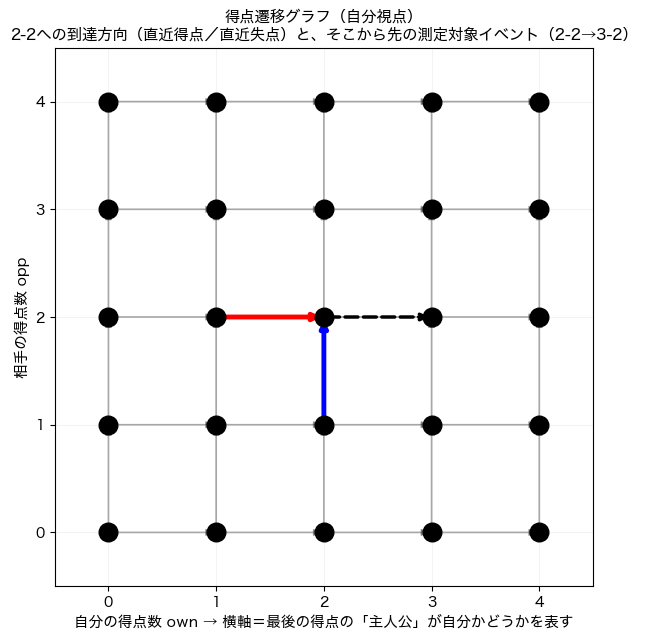

In [201]:
fig, ax = plot_transition_diagram(
    target_own=2, target_opp=2,
    title="得点遷移グラフ（自分視点）\n2-2への到達方向（直近得点／直近失点）と、そこから先の測定対象イベント（2-2→3-2）",
)

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_2_to_3_2_transition_diagram.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()

In [202]:
CATEGORY_ORDER_4 = ["直近得点", "直近失点"]

survival_df_4 = build_arrival_split_events(df_all, target_own=2, target_opp=2)
n_event = int((survival_df_4["event"] == 1).sum())
n_cens_opp = int((survival_df_4["censor_type"] == "opponent").sum())
n_cens_end = int((survival_df_4["censor_type"] == "match_end").sum())
print(f"観測数: {len(survival_df_4)}（イベント: {n_event}, 相手の得点による打ち切り: {n_cens_opp}, "
      f"試合終了による打ち切り: {n_cens_end}）")

survival_df_4.groupby(["category", "event"]).size().unstack(fill_value=0).reindex(CATEGORY_ORDER_4)

観測数: 420（イベント: 93, 相手の得点による打ち切り: 93, 試合終了による打ち切り: 234）


event,0,1
category,,
直近得点,169,41
直近失点,158,52


In [203]:
max_wait_4 = survival_df_4["waiting_time"].max()
BIN_EDGES_4 = np.arange(0, np.ceil(max_wait_4 / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait_4:.2f}分 -> ビン境界: 0〜{BIN_EDGES_4[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES_4)-1}ビン）")

km_fits_4, km_summary_4 = fit_km_by_category(survival_df_4, CATEGORY_ORDER_4)
km_summary_4

最大待ち時間: 58.12分 -> ビン境界: 0〜60分（5分刻み、12ビン）


,n,イベント数,相手の得点による打ち切り,試合終了による打ち切り,生存時間中央値me(分)
区分,,,,,
直近得点,210,41,52,117,inf
直近失点,210,52,41,117,inf


保存しました: ./figures/survival_score_progression_2_2_to_3_2_histograms.png


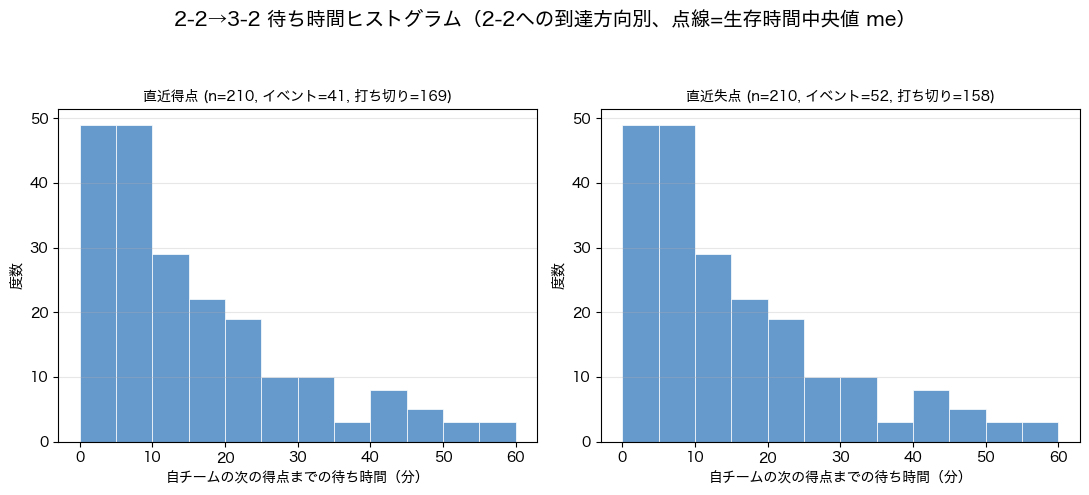

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, cat in zip(axes, CATEGORY_ORDER_4):
    sub = survival_df_4[survival_df_4["category"] == cat]
    plot_hist_with_km_median(ax, sub, km_fits_4[cat], cat, BIN_EDGES_4)

fig.suptitle("2-2→3-2 待ち時間ヒストグラム（2-2への到達方向別、点線=生存時間中央値 me）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_2_to_3_2_histograms.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()

保存しました: ./figures/survival_score_progression_2_2_to_3_2_km_curves_grid.png


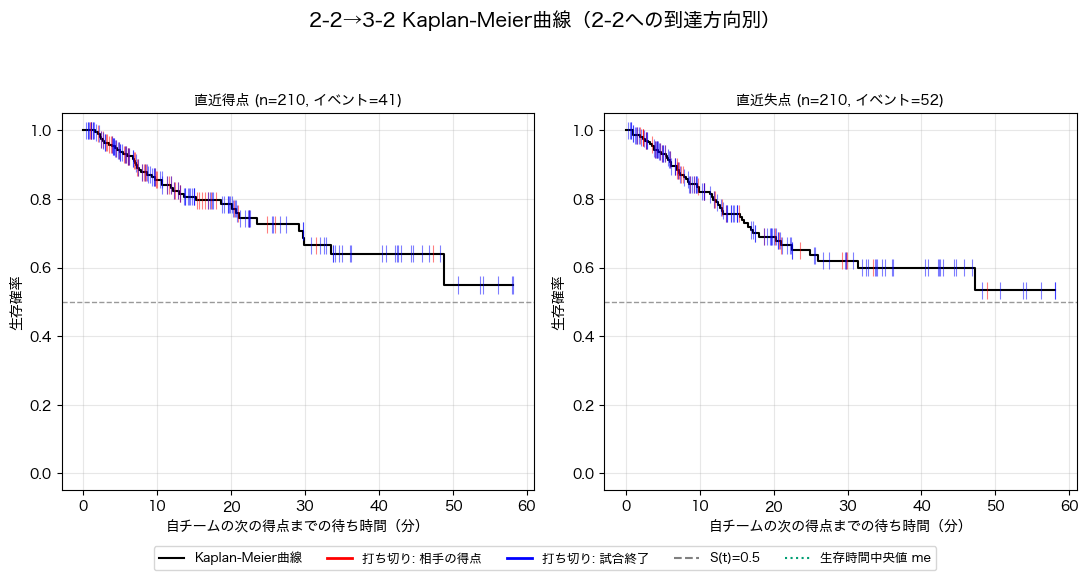

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

for ax, cat in zip(axes, CATEGORY_ORDER_4):
    kmf = km_fits_4[cat]
    sub = survival_df_4[survival_df_4["category"] == cat]
    if kmf is None:
        ax.axis("off")
        continue
    plot_km_with_censor_marks(ax, sub, kmf, cat)

legend_handles = [
    Line2D([], [], color="black", linewidth=1.5, label="Kaplan-Meier曲線"),
    Line2D([], [], color=CENSOR_OPPONENT_COLOR, linewidth=2, label="打ち切り: 相手の得点"),
    Line2D([], [], color=CENSOR_MATCHEND_COLOR, linewidth=2, label="打ち切り: 試合終了"),
    Line2D([], [], color="gray", linewidth=1.5, linestyle="--", label="S(t)=0.5"),
    Line2D([], [], color=MEDIAN_COLOR, linewidth=1.5, linestyle=":", label="生存時間中央値 me"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.05))

fig.suptitle("2-2→3-2 Kaplan-Meier曲線（2-2への到達方向別）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_2_to_3_2_km_curves_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"保存しました: {out_path}")
plt.show()

保存しました: ./figures/survival_score_progression_2_2_to_3_2_km_curves_overlay.png


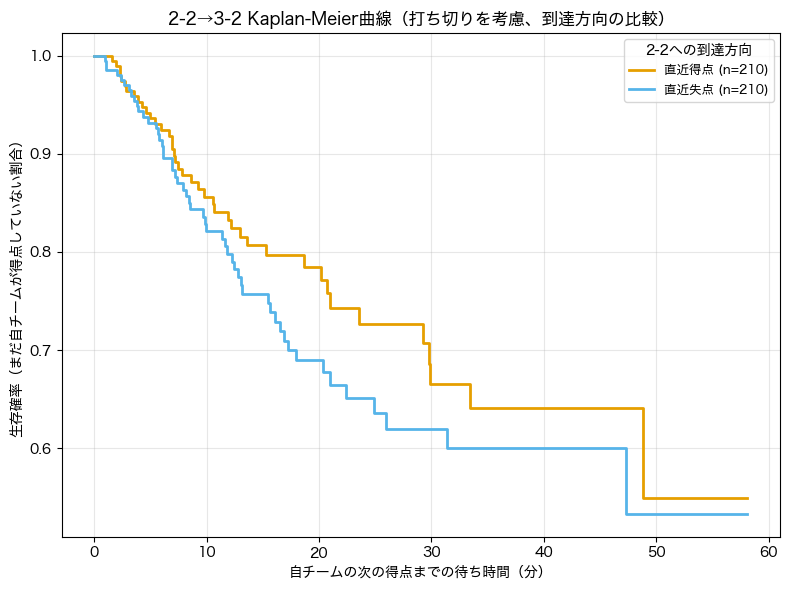

In [206]:
CATEGORY_COLORS_4 = {"直近得点": OWN_GOAL_COLOR, "直近失点": OPP_GOAL_COLOR}

fig, ax = plt.subplots(figsize=(8, 6))

for cat in CATEGORY_ORDER_4:
    kmf = km_fits_4[cat]
    if kmf is None:
        continue
    kmf.plot_survival_function(ax=ax, ci_show=False, show_censors=False,
                                color=CATEGORY_COLORS_4[cat], linewidth=2)

ax.set_xlabel("自チームの次の得点までの待ち時間（分）")
ax.set_ylabel("生存確率（まだ自チームが得点していない割合）")
ax.set_title("2-2→3-2 Kaplan-Meier曲線（打ち切りを考慮、到達方向の比較）")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right", title="2-2への到達方向")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/survival_score_progression_2_2_to_3_2_km_curves_overlay.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()

In [207]:
pairwise_summary_4 = run_logrank_tests(survival_df_4, CATEGORY_ORDER_4)
pairwise_summary_4

=== 2区分一括のログランク検定（打ち切りを考慮） ===



=== 区分間のペアワイズ・ログランク検定（p値昇順、比較数=1） ===
有意水準: * p<0.10, ** p<0.05, *** p<0.01


,,test_statistic,p,-log2(p),p_bonferroni
直近失点,直近得点,1.301075,2.540169e-01,1.977004,2.540169e-01
